# Spatial Analysis of Cultural Participation in India

This notebook performs an Exploratory Spatial Data Analysis (ESDA) of cultural participation across Indian states using data from the NSS 47th Round (1991-92).
The first critical step is harmonizing region names between the Stata data file (32 states/UTs) and the GeoJSON map (36 regions), then creating a 32-region map consistent with the data.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## 1. Load Data

In [ ]:
# Load Stata cultural data (NSS 47th Round, 1991-92)
df_stata = pd.read_stata("../data/Cultural_Data_India/Final_state_LC_CH.dta")
print(f"Stata data: {df_stata.shape[0]} states, {df_stata.shape[1]} columns")
print(f"Columns: {list(df_stata.columns)}")
df_stata.head()

Stata data: 32 states, 7 columns
Columns: ['State_num', 'LC_Performance', 'LC_Telecast', 'SC', 'CH_relig', 'LC_shows', 'Sports']


,State_num,LC_Performance,LC_Telecast,SC,CH_relig,LC_shows,Sports
0,A & N Islands,-0.039257,0.218096,0.105269,-0.142054,1.016912,-0.229062
1,Andhra Pradesh,-0.011268,0.259332,-0.003002,-0.103771,-0.137962,-0.306077
2,Arunachal Pradesh,0.025483,-0.498378,0.044571,-0.104606,0.067274,-0.113826
3,Assam,-0.009383,-0.050606,0.091993,0.275306,-0.124625,-0.038665
4,Bihar,-0.011525,-0.283571,-0.015918,-0.083530,-0.095251,0.141808


In [ ]:
# Load GeoJSON map (36 regions, ~2014-2019 administrative divisions)
gdf36 = gpd.read_file("../data/maps/india36.geojson")
print(f"GeoJSON: {gdf36.shape[0]} regions")
print(f"Properties: {list(gdf36.columns)}")
gdf36.head()

GeoJSON: 36 regions
Properties: ['id', 'region', 'geometry']


,id,region,geometry
0,1,Andaman and Nicobar Islands,"MULTIPOLYGON (((93.84861 7.24051, 93.80986 7.2..."
1,2,Andhra Pradesh,"MULTIPOLYGON (((81.1061 17.82436, 81.09749 17...."
2,3,Arunachal Pradesh,"MULTIPOLYGON (((95.2373 26.67984, 95.25969 26...."
3,4,Assam,"MULTIPOLYGON (((95.19587 27.03716, 95.21414 27..."
4,5,Bihar,"MULTIPOLYGON (((88.11223 26.53886, 88.0997 26...."


## 2. Name Harmonization

### 2.1 Side-by-side comparison of region names

In [ ]:
stata_names = sorted(df_stata["State_num"].unique())
geojson_names = sorted(gdf36["region"].unique())

print(f"Stata: {len(stata_names)} states")
print(f"GeoJSON: {len(geojson_names)} regions")
print()

# Show exact matches
exact_matches = set(stata_names) & set(geojson_names)
print(f"--- Exact matches ({len(exact_matches)}) ---")
for name in sorted(exact_matches):
    print(f"  {name}")

# Show names only in Stata
stata_only = set(stata_names) - set(geojson_names)
print(f"\n--- In Stata only ({len(stata_only)}) ---")
for name in sorted(stata_only):
    print(f"  {name}")

# Show names only in GeoJSON
geojson_only = set(geojson_names) - set(stata_names)
print(f"\n--- In GeoJSON only ({len(geojson_only)}) ---")
for name in sorted(geojson_only):
    print(f"  {name}")

Stata: 32 states
GeoJSON: 36 regions

--- Exact matches (23) ---
  Andhra Pradesh
  Arunachal Pradesh
  Assam
  Bihar
  Goa
  Gujarat
  Haryana
  Himachal Pradesh
  Karnataka
  Kerala
  Madhya Pradesh
  Maharashtra
  Manipur
  Meghalaya
  Mizoram
  Nagaland
  Punjab
  Rajasthan
  Sikkim
  Tamil Nadu
  Tripura
  Uttar Pradesh
  West Bengal

--- In Stata only (9) ---
  A & N Islands
  Chandigarh
  Dadra & Nagar Haveli
  Daman & Diu
  Delhi
  Jammu & Kashmir
  Lakshdweep
  Orissa
  Pondicherry

--- In GeoJSON only (13) ---
  Andaman and Nicobar Islands
  Chandigarth
  Chhattisgarh
  Dadra and Nagar Haveli
  Daman and Diu
  Jammu and Kashmir
  Jharkhand
  Lakshadweep
  NCT of Delhi
  Odisha
  Puducherry
  Telangana
  Uttarakhand


### 2.2 Verified name mapping

Each mapping has been verified via web research. We rename GeoJSON names to match the Stata conventions.

| # | Stata name | GeoJSON name | Reason |
|---|-----------|-------------|--------|
| 1 | A & N Islands | Andaman and Nicobar Islands | Survey abbreviation vs full official name |
| 2 | Chandigarh | Chandigarth | **Typo in GeoJSON** — correct spelling is "Chandigarh" |
| 3 | Dadra & Nagar Haveli | Dadra and Nagar Haveli | `&` vs `and` |
| 4 | Daman & Diu | Daman and Diu | `&` vs `and` |
| 5 | Delhi | NCT of Delhi | Short name vs official name |
| 6 | Jammu & Kashmir | Jammu and Kashmir | `&` vs `and` |
| 7 | Lakshdweep | Lakshadweep | **Typo in Stata** — correct is "Lakshadweep"; we use the Stata spelling for consistency |
| 8 | Orissa | Odisha | Old name (pre-2011 rename) |
| 9 | Pondicherry | Puducherry | Old name (pre-2006 rename) |

In [ ]:
# Mapping: GeoJSON name -> Stata name (harmonize to Stata conventions)
geojson_to_stata = {
    "Andaman and Nicobar Islands": "A & N Islands",
    "Chandigarth": "Chandigarh",        # Fix GeoJSON typo
    "Dadra and Nagar Haveli": "Dadra & Nagar Haveli",
    "Daman and Diu": "Daman & Diu",
    "NCT of Delhi": "Delhi",
    "Jammu and Kashmir": "Jammu & Kashmir",
    "Lakshadweep": "Lakshdweep",         # Match Stata typo for merge
    "Odisha": "Orissa",                  # Old name used in Stata
    "Puducherry": "Pondicherry",         # Old name used in Stata
}

# Apply name harmonization to GeoJSON
gdf36["region_harmonized"] = gdf36["region"].replace(geojson_to_stata)

# Verify the mapping worked
print("Name changes applied:")
changed = gdf36[gdf36["region"] != gdf36["region_harmonized"]][["region", "region_harmonized"]]
print(changed.to_string(index=False))

Name changes applied:
                     region    region_harmonized
Andaman and Nicobar Islands        A & N Islands
                Chandigarth           Chandigarh
     Dadra and Nagar Haveli Dadra & Nagar Haveli
              Daman and Diu          Daman & Diu
          Jammu and Kashmir      Jammu & Kashmir
                Lakshadweep           Lakshdweep
               NCT of Delhi                Delhi
                     Odisha               Orissa
                 Puducherry          Pondicherry


### 2.3 Compatibility report after harmonization

In [ ]:
harmonized_names = set(gdf36["region_harmonized"].unique())
stata_name_set = set(stata_names)

matched = harmonized_names & stata_name_set
geojson_unmatched = harmonized_names - stata_name_set
stata_unmatched = stata_name_set - harmonized_names

print(f"=== Compatibility Report ===")
print(f"Matched regions: {len(matched)} of {len(stata_name_set)} Stata states")
print(f"GeoJSON regions without Stata data: {len(geojson_unmatched)}")
print(f"Stata states without GeoJSON match: {len(stata_unmatched)}")

if geojson_unmatched:
    print(f"\nGeoJSON-only (newer states, no data):")
    for name in sorted(geojson_unmatched):
        print(f"  {name}")

if stata_unmatched:
    print(f"\n*** WARNING: Stata states with no GeoJSON match ***")
    for name in sorted(stata_unmatched):
        print(f"  {name}")
else:
    print("\nAll Stata states have a GeoJSON match.")

=== Compatibility Report ===
Matched regions: 32 of 32 Stata states
GeoJSON regions without Stata data: 4
Stata states without GeoJSON match: 0

GeoJSON-only (newer states, no data):
  Chhattisgarh
  Jharkhand
  Telangana
  Uttarakhand

All Stata states have a GeoJSON match.


## 3. Create 32-Region Map (Dissolve Newer States)

The 4 newer states that don't exist in the Stata data were carved from parent states after 1991-92:

| Newer state | Carved from | Year |
|------------|-------------|------|
| Chhattisgarh | Madhya Pradesh | 2000 |
| Jharkhand | Bihar | 2000 |
| Uttarakhand | Uttar Pradesh | 2000 |
| Telangana | Andhra Pradesh | 2014 |

We dissolve these back into their parent states to create a 32-region map matching the Stata data.

In [ ]:
# Map newer states to their parent states
dissolve_map = {
    "Chhattisgarh": "Madhya Pradesh",
    "Jharkhand": "Bihar",
    "Uttarakhand": "Uttar Pradesh",
    "Telangana": "Andhra Pradesh",
}

# Create dissolve column: use harmonized name, but remap newer states to parents
gdf36["region_dissolve"] = gdf36["region_harmonized"].replace(dissolve_map)

print("Regions to be dissolved:")
dissolved = gdf36[gdf36["region_harmonized"] != gdf36["region_dissolve"]][
    ["region_harmonized", "region_dissolve"]
]
print(dissolved.to_string(index=False))

Regions to be dissolved:
region_harmonized region_dissolve
     Chhattisgarh  Madhya Pradesh
        Jharkhand           Bihar
        Telangana  Andhra Pradesh
      Uttarakhand   Uttar Pradesh


In [ ]:
# Dissolve geometries by the dissolve column
# Select only the dissolve key + geometry to avoid duplicate column issues
gdf_prep = gdf36[["region_dissolve", "geometry"]].copy()
gdf32 = gdf_prep.dissolve(by="region_dissolve").reset_index()
gdf32 = gdf32.rename(columns={"region_dissolve": "region"})

print(f"New map: {len(gdf32)} regions")
assert len(gdf32) == 32, f"Expected 32 regions, got {len(gdf32)}"
print("32-region map created successfully.")

New map: 32 regions
32-region map created successfully.


In [ ]:
# Save the 32-region GeoJSON
gdf32.to_file("../data/maps/india32.geojson", driver="GeoJSON")
print("Saved: data/maps/india32.geojson")

Saved: data/maps/india32.geojson


### 3.1 Verification: boundary plot

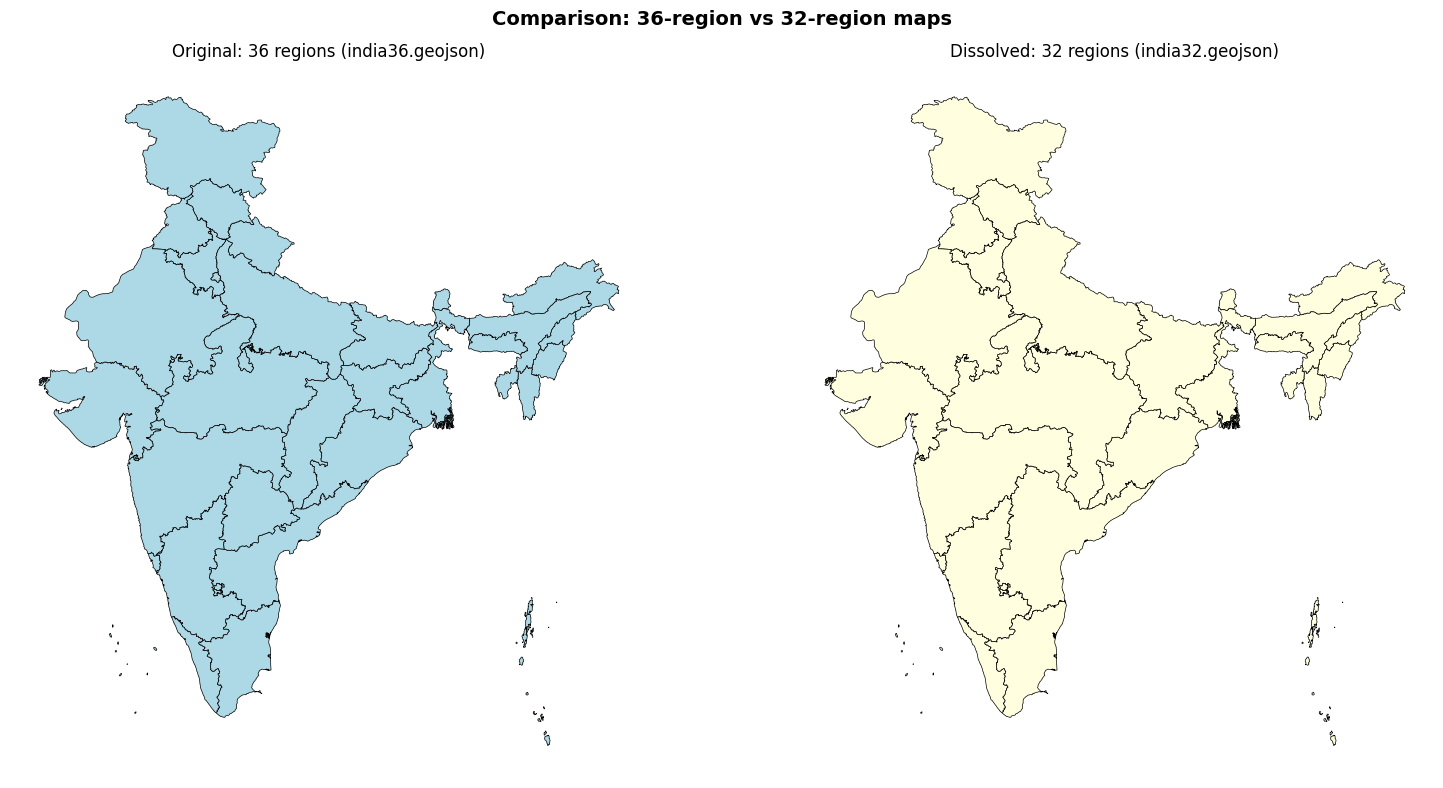

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gdf36.plot(ax=axes[0], edgecolor="black", facecolor="lightblue", linewidth=0.5)
axes[0].set_title(f"Original: {len(gdf36)} regions (india36.geojson)")
axes[0].set_axis_off()

gdf32.plot(ax=axes[1], edgecolor="black", facecolor="lightyellow", linewidth=0.5)
axes[1].set_title(f"Dissolved: {len(gdf32)} regions (india32.geojson)")
axes[1].set_axis_off()

plt.suptitle("Comparison: 36-region vs 32-region maps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Merge Cultural Data with Map

In [ ]:
# Merge: 32-region GeoJSON + Stata cultural data
gdf_merged = gdf32.merge(df_stata, left_on="region", right_on="State_num", how="left")

# Check for any unmatched regions
n_matched = gdf_merged["State_num"].notna().sum()
n_missing = gdf_merged["State_num"].isna().sum()
print(f"Matched: {n_matched} / {len(gdf32)} regions")
print(f"Missing data: {n_missing}")

if n_missing > 0:
    print("\n*** WARNING: Unmatched regions ***")
    print(gdf_merged[gdf_merged["State_num"].isna()]["region"].tolist())
else:
    print("\nPerfect merge: all 32 regions have cultural data.")

gdf_merged.head()

Matched: 32 / 32 regions
Missing data: 0

Perfect merge: all 32 regions have cultural data.


,region,geometry,State_num,LC_Performance,LC_Telecast,SC,CH_relig,LC_shows,Sports
0,A & N Islands,"MULTIPOLYGON (((92.77383 9.12596, 92.73327 9.1...",A & N Islands,-0.039257,0.218096,0.105269,-0.142054,1.016912,-0.229062
1,Andhra Pradesh,"MULTIPOLYGON (((81.20038 17.85444, 81.26252 17...",Andhra Pradesh,-0.011268,0.259332,-0.003002,-0.103771,-0.137962,-0.306077
2,Arunachal Pradesh,"POLYGON ((95.2373 26.67984, 95.25969 26.67984,...",Arunachal Pradesh,0.025483,-0.498378,0.044571,-0.104606,0.067274,-0.113826
3,Assam,"POLYGON ((95.19587 27.03716, 95.21414 27.02763...",Assam,-0.009383,-0.050606,0.091993,0.275306,-0.124625,-0.038665
4,Bihar,"POLYGON ((87.77667 25.1529, 87.77827 25.09978,...",Bihar,-0.011525,-0.283571,-0.015918,-0.083530,-0.095251,0.141808


## 5. Choropleth Maps

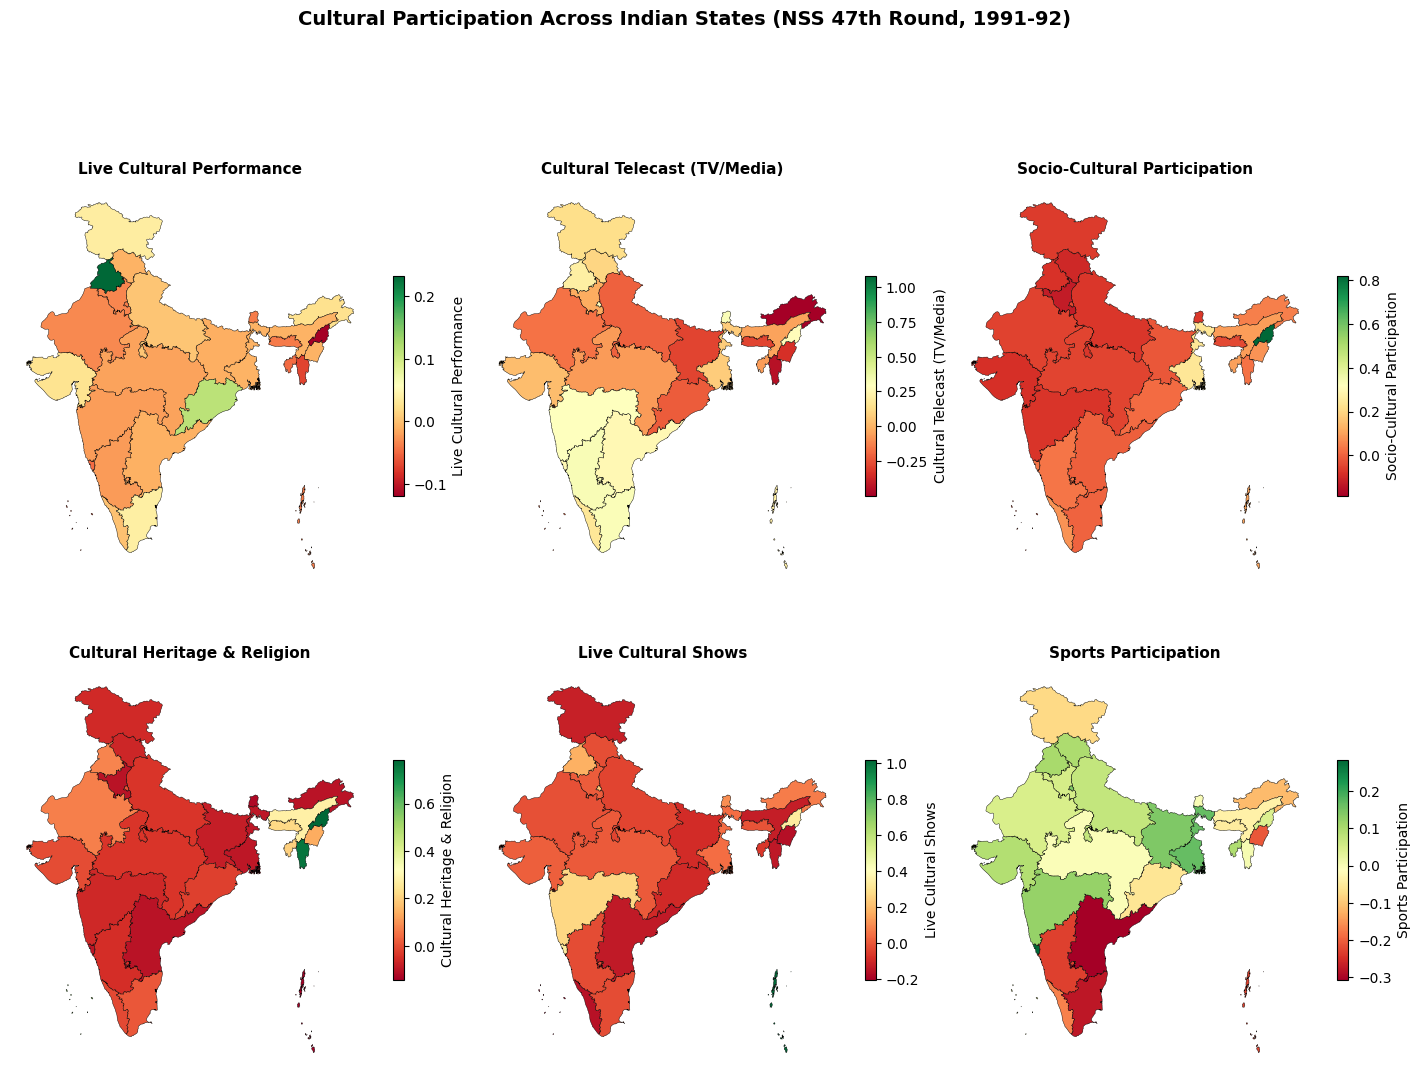

In [ ]:
variables = ["LC_Performance", "LC_Telecast", "SC", "CH_relig", "LC_shows", "Sports"]
var_labels = {
    "LC_Performance": "Live Cultural Performance",
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "SC": "Socio-Cultural Participation",
    "CH_relig": "Cultural Heritage & Religion",
    "LC_shows": "Live Cultural Shows",
    "Sports": "Sports Participation",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    gdf_merged.plot(
        column=var,
        ax=axes[i],
        legend=True,
        legend_kwds={"shrink": 0.5, "label": var_labels[var]},
        cmap="RdYlGn",
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    axes[i].set_title(var_labels[var], fontsize=11, fontweight="bold", pad=8)
    axes[i].set_axis_off()

fig.suptitle(
    "Cultural Participation Across Indian States (NSS 47th Round, 1991-92)",
    fontsize=14, fontweight="bold", y=1.01,
)
fig.subplots_adjust(hspace=0.1, wspace=0.05)
plt.show()


In [ ]:
# Summary statistics
print("Summary Statistics of Cultural Variables")
print("=" * 60)
print(gdf_merged[variables].describe().round(3))

Summary Statistics of Cultural Variables
       LC_Performance  LC_Telecast      SC  CH_relig  LC_shows  Sports
count          32.000       32.000  32.000    32.000    32.000  32.000
mean           -0.013        0.051   0.019     0.047     0.037  -0.007
std             0.061        0.315   0.168     0.239     0.242   0.148
min            -0.118       -0.498  -0.183    -0.142    -0.205  -0.306
25%            -0.041       -0.190  -0.065    -0.097    -0.124  -0.091
50%            -0.022        0.070  -0.020    -0.041    -0.024   0.001
75%            -0.007        0.264   0.052     0.072     0.077   0.096
max             0.233        1.083   0.820     0.785     1.017   0.284


## 6. Load and Merge Nighttime Lights (NTL) Data

We load district-level NTL data from the main project dataset and aggregate it to the state level to match our 32-region cultural data.
We then create a **Nighttime Lights Index** (normalized 0-1 via min-max scaling) so that the economic development proxy is on a comparable scale to the cultural variables.


In [ ]:
# Load district-level NTL data
df_ntl = pd.read_stata("../data/india520.dta")
print(f"NTL data: {df_ntl.shape[0]} districts, {df_ntl.shape[1]} columns")

# Dissolve newer states back to 1991-92 parent states
ntl_state_map = {
    "Chhattisgarh": "Madhya Pradesh",
    "Jharkhand": "Bihar",
    "Uttaranchal": "Uttar Pradesh",
    "NCT of Delhi": "Delhi",
}
df_ntl["state_harmonized"] = df_ntl["state"].replace(ntl_state_map)

# Aggregate to state-level means
ntl_state = (
    df_ntl.groupby("state_harmonized")[["log_light96_rcr_cap", "light_growth96_10rcr_cap"]]
    .mean()
    .reset_index()
    .rename(columns={
        "state_harmonized": "region",
        "log_light96_rcr_cap": "NTL_raw",
        "light_growth96_10rcr_cap": "NTL_growth",
    })
)

# Create NTL Index: min-max normalization to [0, 1]
ntl_min = ntl_state["NTL_raw"].min()
ntl_max = ntl_state["NTL_raw"].max()
ntl_state["NTL_index"] = (ntl_state["NTL_raw"] - ntl_min) / (ntl_max - ntl_min)

print(f"Aggregated to {len(ntl_state)} states")
print(f"\nNTL Index (min-max normalized to 0-1):")
print(f"  Raw range: [{ntl_min:.3f}, {ntl_max:.3f}]")
print(f"  Index range: [{ntl_state['NTL_index'].min():.3f}, {ntl_state['NTL_index'].max():.3f}]")
print(f"  Mean: {ntl_state['NTL_index'].mean():.3f}, Std: {ntl_state['NTL_index'].std():.3f}")

ntl_state[["region", "NTL_raw", "NTL_index", "NTL_growth"]].sort_values(
    "NTL_index", ascending=False
)


NTL data: 520 districts, 341 columns
Aggregated to 25 states

NTL Index (min-max normalized to 0-1):
  Raw range: [-6.525, -3.460]
  Index range: [0.000, 1.000]
  Mean: 0.574, Std: 0.310


,region,NTL_raw,NTL_index,NTL_growth
3,Chandigarh,-3.459935,1.000000,0.010627
19,Punjab,-3.561247,0.966950,0.017447
7,Haryana,-3.666641,0.932568,0.019910
4,Delhi,-3.750995,0.905049,0.010994
5,Goa,-3.843256,0.874951,0.021198
6,Gujarat,-3.845271,0.874294,-0.003671
13,Maharashtra,-3.899936,0.856461,-0.005715
20,Rajasthan,-4.013976,0.819258,0.024449
0,Andhra Pradesh,-4.034756,0.812479,0.026855
22,Tamil Nadu,-4.184392,0.763664,0.025150


In [ ]:
# Merge NTL data with cultural+map GeoDataFrame
gdf_full = gdf_merged.merge(ntl_state, on="region", how="left")

n_with_ntl = gdf_full["NTL_index"].notna().sum()
n_without = gdf_full["NTL_index"].isna().sum()
print(f"States with both cultural + NTL data: {n_with_ntl}")
print(f"States with cultural data only (no NTL): {n_without}")

if n_without > 0:
    print(f"\nStates without NTL data:")
    print(gdf_full[gdf_full["NTL_index"].isna()]["region"].tolist())

# Create analysis subset (states with complete data)
gdf_analysis = gdf_full.dropna(subset=["NTL_index"]).copy()
print(f"\nAnalysis sample: {len(gdf_analysis)} states with complete data")


States with both cultural + NTL data: 25
States with cultural data only (no NTL): 7

States without NTL data:
['A & N Islands', 'Assam', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Lakshdweep', 'Pondicherry', 'Tripura']

Analysis sample: 25 states with complete data


**Data limitation:** The NTL dataset (`india520.dta`) covers only 25 of the 32 states in the cultural data. The 7 missing states are: A & N Islands, Assam, Dadra & Nagar Haveli, Daman & Diu, Lakshadweep, Pondicherry, and Tripura. Most are small union territories, but the absence of **Assam** (high heritage/religion participation) and **Tripura** (high socio-cultural participation) means the Northeastern cultural signal may be underrepresented in the analysis below. Results should be interpreted with this coverage gap in mind.

## 7. Choropleth Maps \u2014 NTL Index vs Cultural Geography

Comparing the spatial distribution of the NTL Index (economic development) with cultural participation variables. Do the maps tell a similar story?


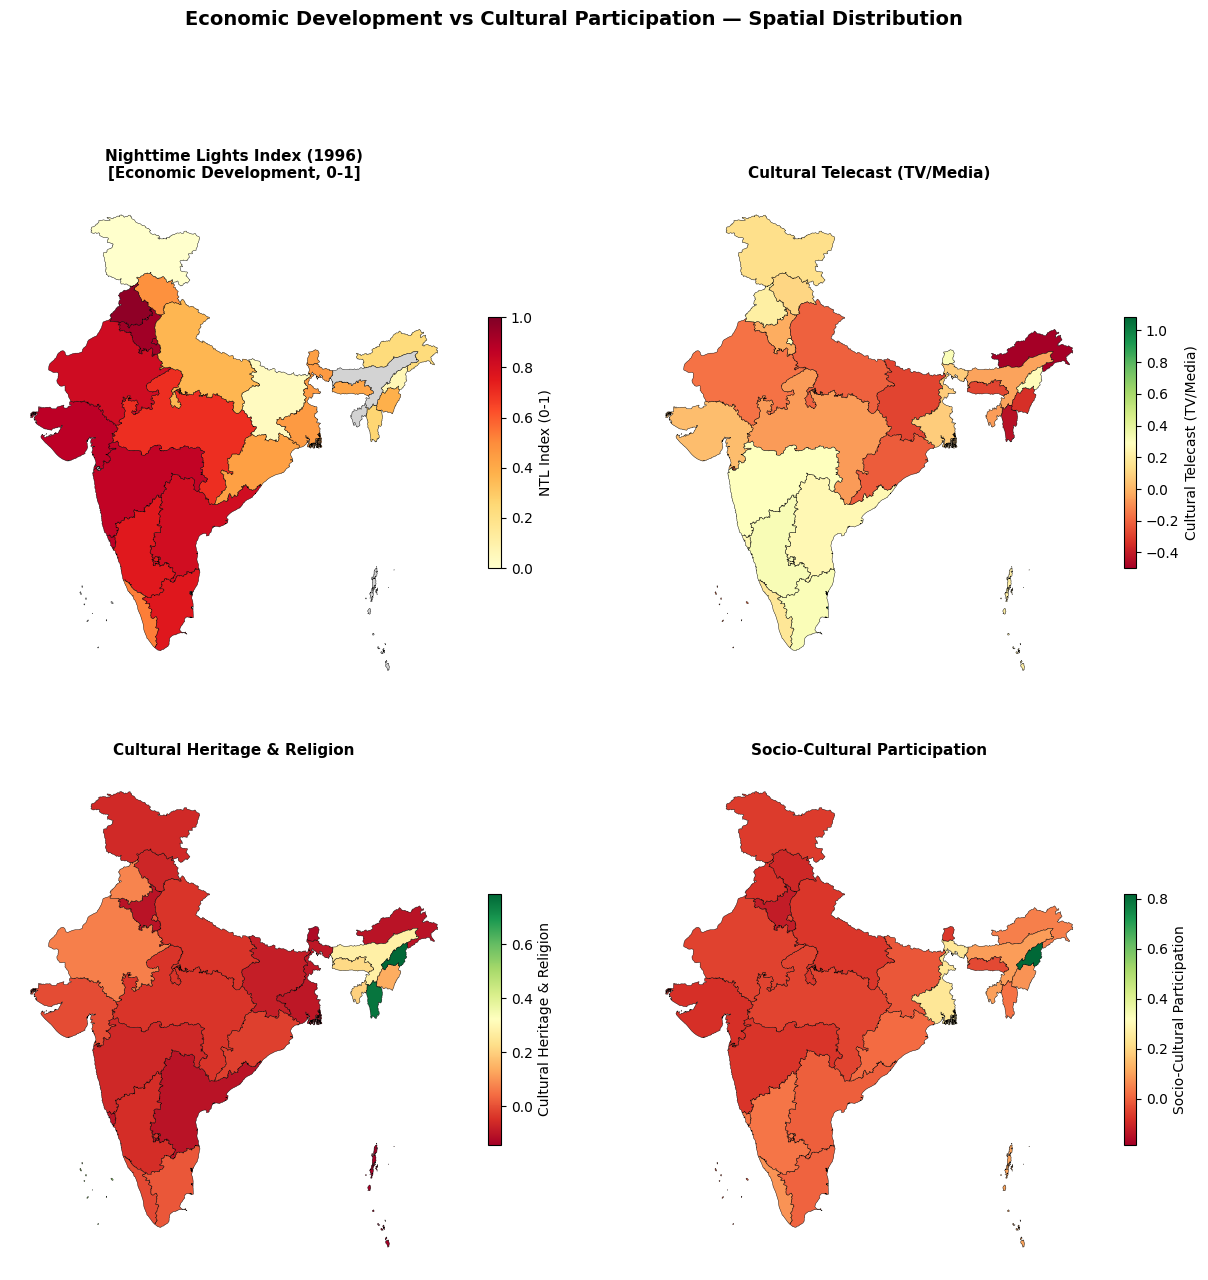

In [ ]:
# Side-by-side: NTL Index vs key cultural variables
cultural_compare = ["LC_Telecast", "CH_relig", "SC"]
cultural_labels = {
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "CH_relig": "Cultural Heritage & Religion",
    "SC": "Socio-Cultural Participation",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# NTL Index map
gdf_full.plot(
    column="NTL_index", ax=axes[0], legend=True,
    legend_kwds={"shrink": 0.5, "label": "NTL Index (0-1)"},
    cmap="YlOrRd", edgecolor="black", linewidth=0.3,
    missing_kwds={"color": "lightgray", "label": "No data"},
)
axes[0].set_title("Nighttime Lights Index (1996)\n[Economic Development, 0-1]",
                  fontsize=11, fontweight="bold", pad=10)
axes[0].set_axis_off()

# Cultural maps
for i, var in enumerate(cultural_compare):
    gdf_full.plot(
        column=var, ax=axes[i + 1], legend=True,
        legend_kwds={"shrink": 0.5, "label": cultural_labels[var]},
        cmap="RdYlGn", edgecolor="black", linewidth=0.3,
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    axes[i + 1].set_title(cultural_labels[var], fontsize=11, fontweight="bold", pad=10)
    axes[i + 1].set_axis_off()

fig.suptitle(
    "Economic Development vs Cultural Participation \u2014 Spatial Distribution",
    fontsize=14, fontweight="bold", y=1.01,
)
fig.subplots_adjust(hspace=0.15, wspace=0.05)
plt.show()


## 8. Scatter Plots \u2014 NTL Index vs Cultural Variables

Each scatter plot shows the relationship between the NTL Index (0-1, x-axis) and a cultural participation variable (y-axis).
States are labeled to identify outliers. Both Pearson and Spearman correlations are reported.


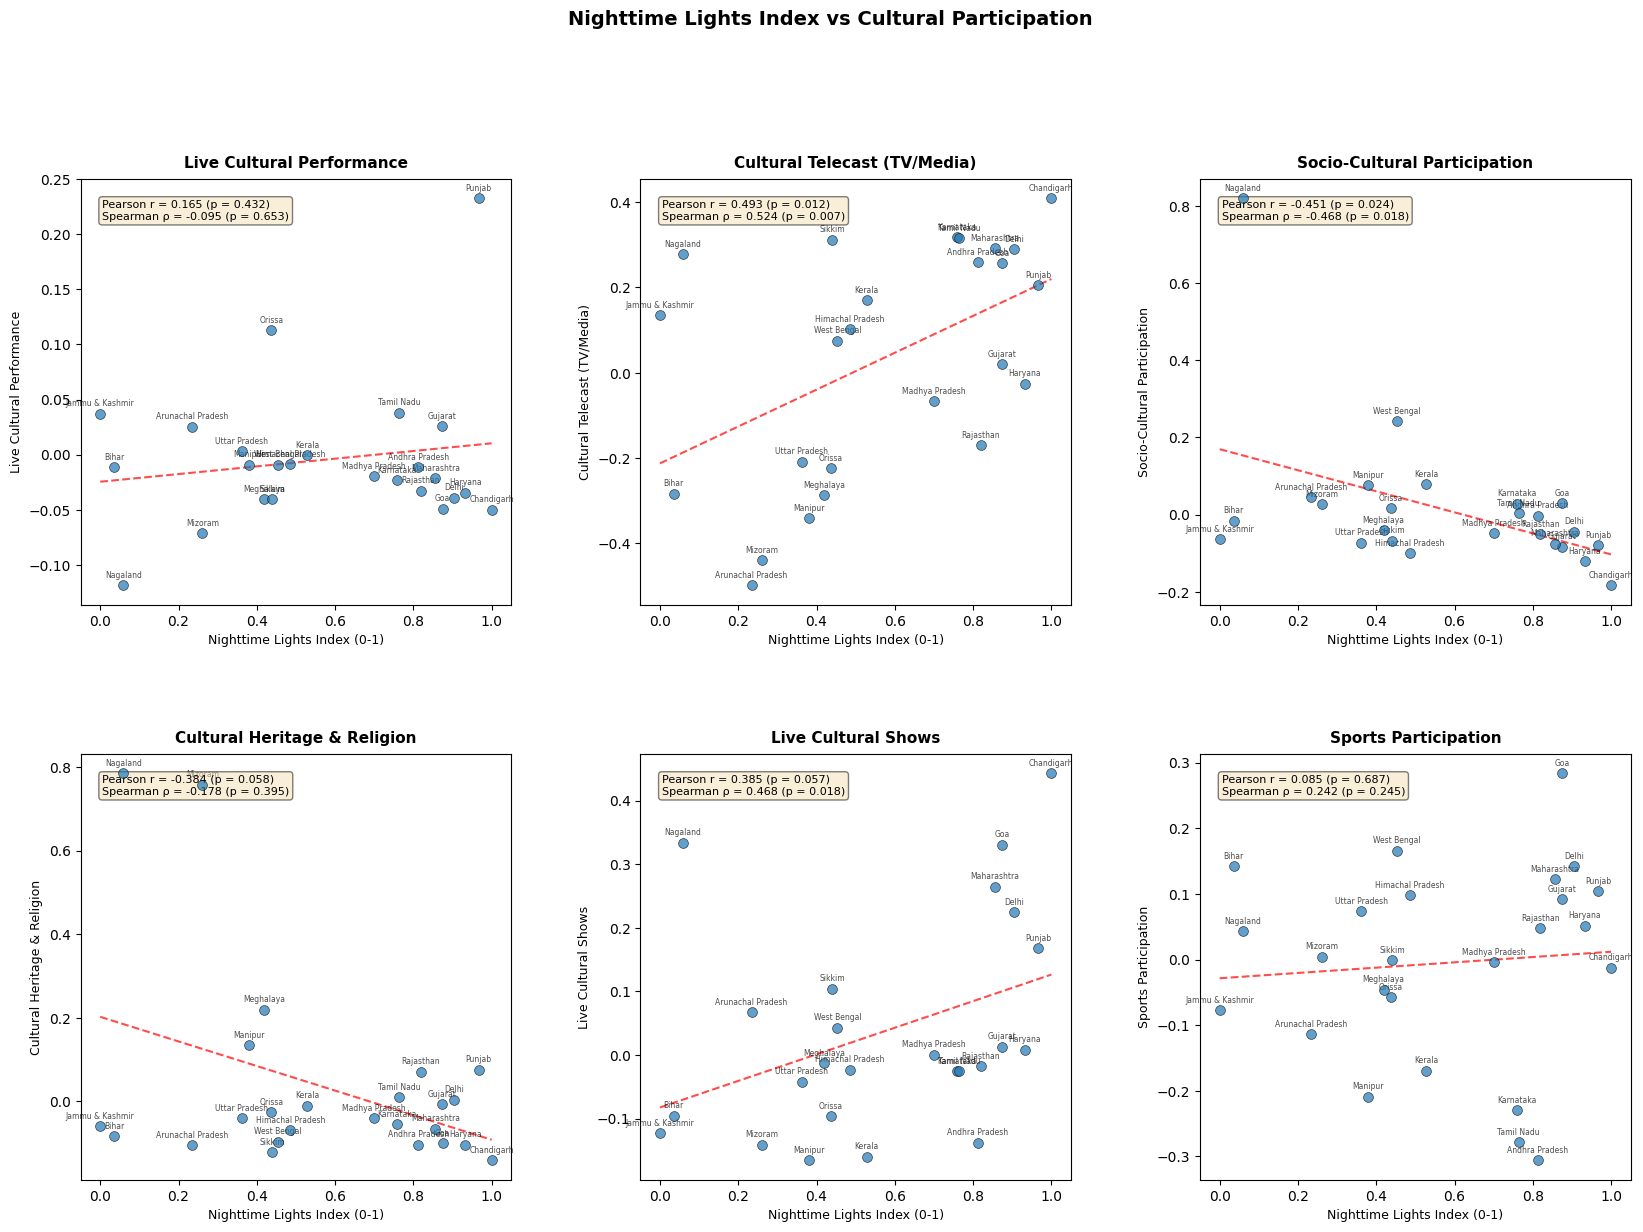

In [ ]:
from scipy import stats

variables = ["LC_Performance", "LC_Telecast", "SC", "CH_relig", "LC_shows", "Sports"]
var_labels = {
    "LC_Performance": "Live Cultural Performance",
    "LC_Telecast": "Cultural Telecast (TV/Media)",
    "SC": "Socio-Cultural Participation",
    "CH_relig": "Cultural Heritage & Religion",
    "LC_shows": "Live Cultural Shows",
    "Sports": "Sports Participation",
}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    x = gdf_analysis["NTL_index"]
    y = gdf_analysis[var]

    ax.scatter(x, y, s=50, alpha=0.7, edgecolors="black", linewidth=0.5, zorder=5)

    # Label each point with state name
    for _, row in gdf_analysis.iterrows():
        ax.annotate(
            row["region"], (row["NTL_index"], row[var]),
            fontsize=5.5, alpha=0.7, ha="center", va="bottom",
            xytext=(0, 4), textcoords="offset points",
        )

    # Fit and plot regression line
    slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, intercept + slope * x_line, "r--", alpha=0.7, linewidth=1.5)

    # Spearman correlation
    rho, p_spearman = stats.spearmanr(x, y)

    ax.set_title(var_labels[var], fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Nighttime Lights Index (0-1)", fontsize=9)
    ax.set_ylabel(var_labels[var], fontsize=9)
    ax.text(
        0.05, 0.95,
        f"Pearson r = {r_val:.3f} (p = {p_val:.3f})\nSpearman \u03c1 = {rho:.3f} (p = {p_spearman:.3f})",
        transform=ax.transAxes, fontsize=8, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

fig.suptitle(
    "Nighttime Lights Index vs Cultural Participation",
    fontsize=14, fontweight="bold", y=1.01,
)
fig.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()


## 9. Correlation Analysis

A comprehensive correlation matrix showing relationships between the NTL Index, NTL growth, and all six cultural participation variables.


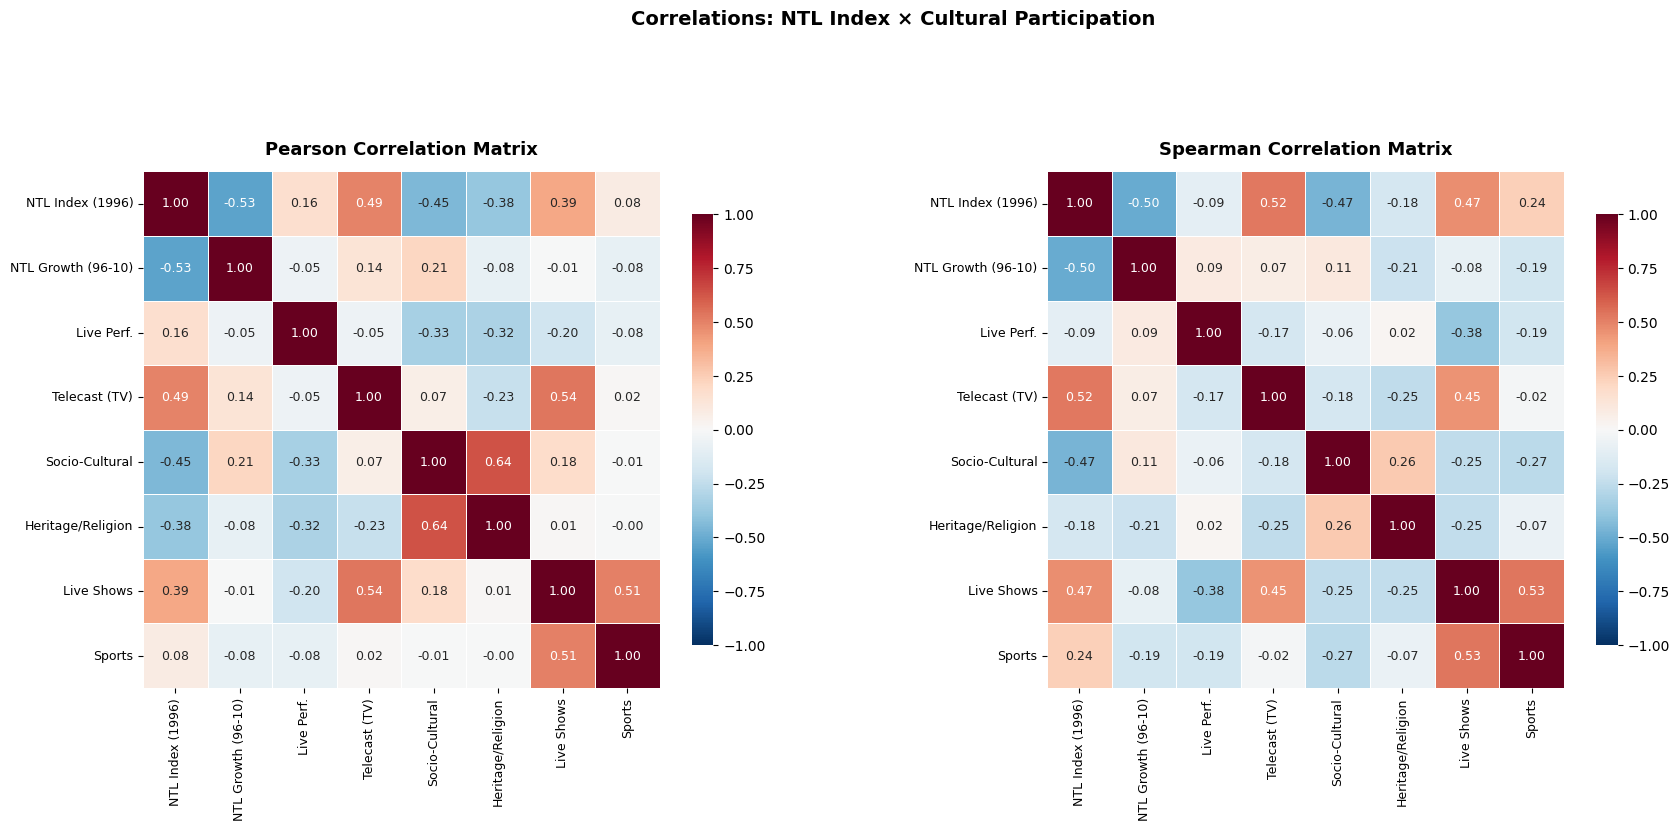

In [ ]:
import seaborn as sns

corr_vars = ["NTL_index", "NTL_growth"] + variables
corr_labels = {
    "NTL_index": "NTL Index (1996)",
    "NTL_growth": "NTL Growth (96-10)",
    "LC_Performance": "Live Perf.",
    "LC_Telecast": "Telecast (TV)",
    "SC": "Socio-Cultural",
    "CH_relig": "Heritage/Religion",
    "LC_shows": "Live Shows",
    "Sports": "Sports",
}

# Pearson correlation
corr_pearson = gdf_analysis[corr_vars].corr(method="pearson")

# Spearman correlation
corr_spearman = gdf_analysis[corr_vars].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson", "Spearman"]):
    corr_display = corr.copy()
    corr_display.index = [corr_labels.get(v, v) for v in corr_display.index]
    corr_display.columns = [corr_labels.get(v, v) for v in corr_display.columns]

    sns.heatmap(
        corr_display, annot=True, fmt=".2f", cmap="RdBu_r",
        vmin=-1, vmax=1, center=0, ax=ax, square=True,
        linewidths=0.5, cbar_kws={"shrink": 0.7},
        annot_kws={"fontsize": 9},
    )
    ax.set_title(f"{title} Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
    ax.tick_params(axis="both", labelsize=9)

fig.suptitle(
    "Correlations: NTL Index \u00d7 Cultural Participation",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.subplots_adjust(wspace=0.4)
plt.show()


In [ ]:
# Statistical significance table for NTL Index correlations
print("Correlation of NTL Index (1996) with Cultural Variables")
print("=" * 75)
print("{:<35} {:>10} {:>10} {:>12} {:>10}".format(
    "Variable", "Pearson r", "p-value", "Spearman \u03c1", "p-value"))
print("-" * 75)

for var in variables:
    x = gdf_analysis["NTL_index"]
    y = gdf_analysis[var]
    r, p_r = stats.pearsonr(x, y)
    rho, p_rho = stats.spearmanr(x, y)
    sig_r = "*" if p_r < 0.05 else (" ." if p_r < 0.10 else "  ")
    sig_rho = "*" if p_rho < 0.05 else (" ." if p_rho < 0.10 else "  ")
    label = var_labels[var]
    print(f"{label:<35} {r:>9.3f}{sig_r} {p_r:>9.3f} {rho:>11.3f}{sig_rho} {p_rho:>9.3f}")

print("-" * 75)
print("Significance: * p < 0.05, . p < 0.10")
n_states = len(gdf_analysis)
print(f"N = {n_states} states")


Correlation of NTL Index (1996) with Cultural Variables
Variable                             Pearson r    p-value   Spearman ρ    p-value
---------------------------------------------------------------------------
Live Cultural Performance               0.165       0.432      -0.095       0.653
Cultural Telecast (TV/Media)            0.493*     0.012       0.524*     0.007
Socio-Cultural Participation           -0.451*     0.024      -0.468*     0.018
Cultural Heritage & Religion           -0.384 .     0.058      -0.178       0.395
Live Cultural Shows                     0.385 .     0.057       0.468*     0.018
Sports Participation                    0.085       0.687       0.242       0.245
---------------------------------------------------------------------------
Significance: * p < 0.05, . p < 0.10
N = 25 states


## 10. LISA Cluster Maps \u2014 NTL Index vs Cultural

We compute Local Indicators of Spatial Association (LISA) for the NTL Index and cultural variables.
Comparing the cluster maps reveals whether spatial clustering of culture mirrors the spatial clustering of economic development.

The approach follows the same methodology as the main project analysis (notebook c03): 6-nearest-neighbor spatial weights, row-standardized, with 999 permutations at p < 0.05.


In [ ]:
from libpysal import weights
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster

# Build spatial weights matrix (6-nearest neighbors) on the analysis subset
W = weights.KNN.from_dataframe(gdf_analysis, k=6)
W.transform = "r"
print(f"Spatial weights: {W.n} regions, k=6, row-standardized")

Spatial weights: 25 regions, k=6, row-standardized


In [ ]:
# Global Moran's I for NTL Index and all cultural variables
print("Global Moran's I \u2014 Spatial Autocorrelation")
print("=" * 60)
print("{:<35} {:>10} {:>10} {:>12}".format(
    "Variable", "Moran I", "p-value", "Significant"))
print("-" * 60)

all_vars = ["NTL_index"] + variables
all_var_labels = {"NTL_index": "NTL Index (1996)"}
all_var_labels.update(var_labels)
for var in all_vars:
    moran = Moran(gdf_analysis[var].values, W, permutations=999)
    sig = "Yes *" if moran.p_sim < 0.05 else ("Marginal ." if moran.p_sim < 0.10 else "No")
    label = all_var_labels[var]
    print(f"{label:<35} {moran.I:>9.3f} {moran.p_sim:>9.3f} {sig:>12}")

print("-" * 60)


Global Moran's I — Spatial Autocorrelation
Variable                               Moran I    p-value  Significant
------------------------------------------------------------
NTL Index (1996)                        0.377     0.002        Yes *
Live Cultural Performance              -0.033     0.398           No
Cultural Telecast (TV/Media)            0.176     0.037        Yes *
Socio-Cultural Participation            0.135     0.002        Yes *
Cultural Heritage & Religion            0.159     0.028        Yes *
Live Cultural Shows                    -0.101     0.280           No
Sports Participation                    0.079     0.102           No
------------------------------------------------------------


### 10.1 LISA Maps: NTL vs Cultural Variables

Each row compares the NTL LISA cluster map (left) with a cultural variable's LISA cluster map (right). Red = High-High clusters, Blue = Low-Low clusters.

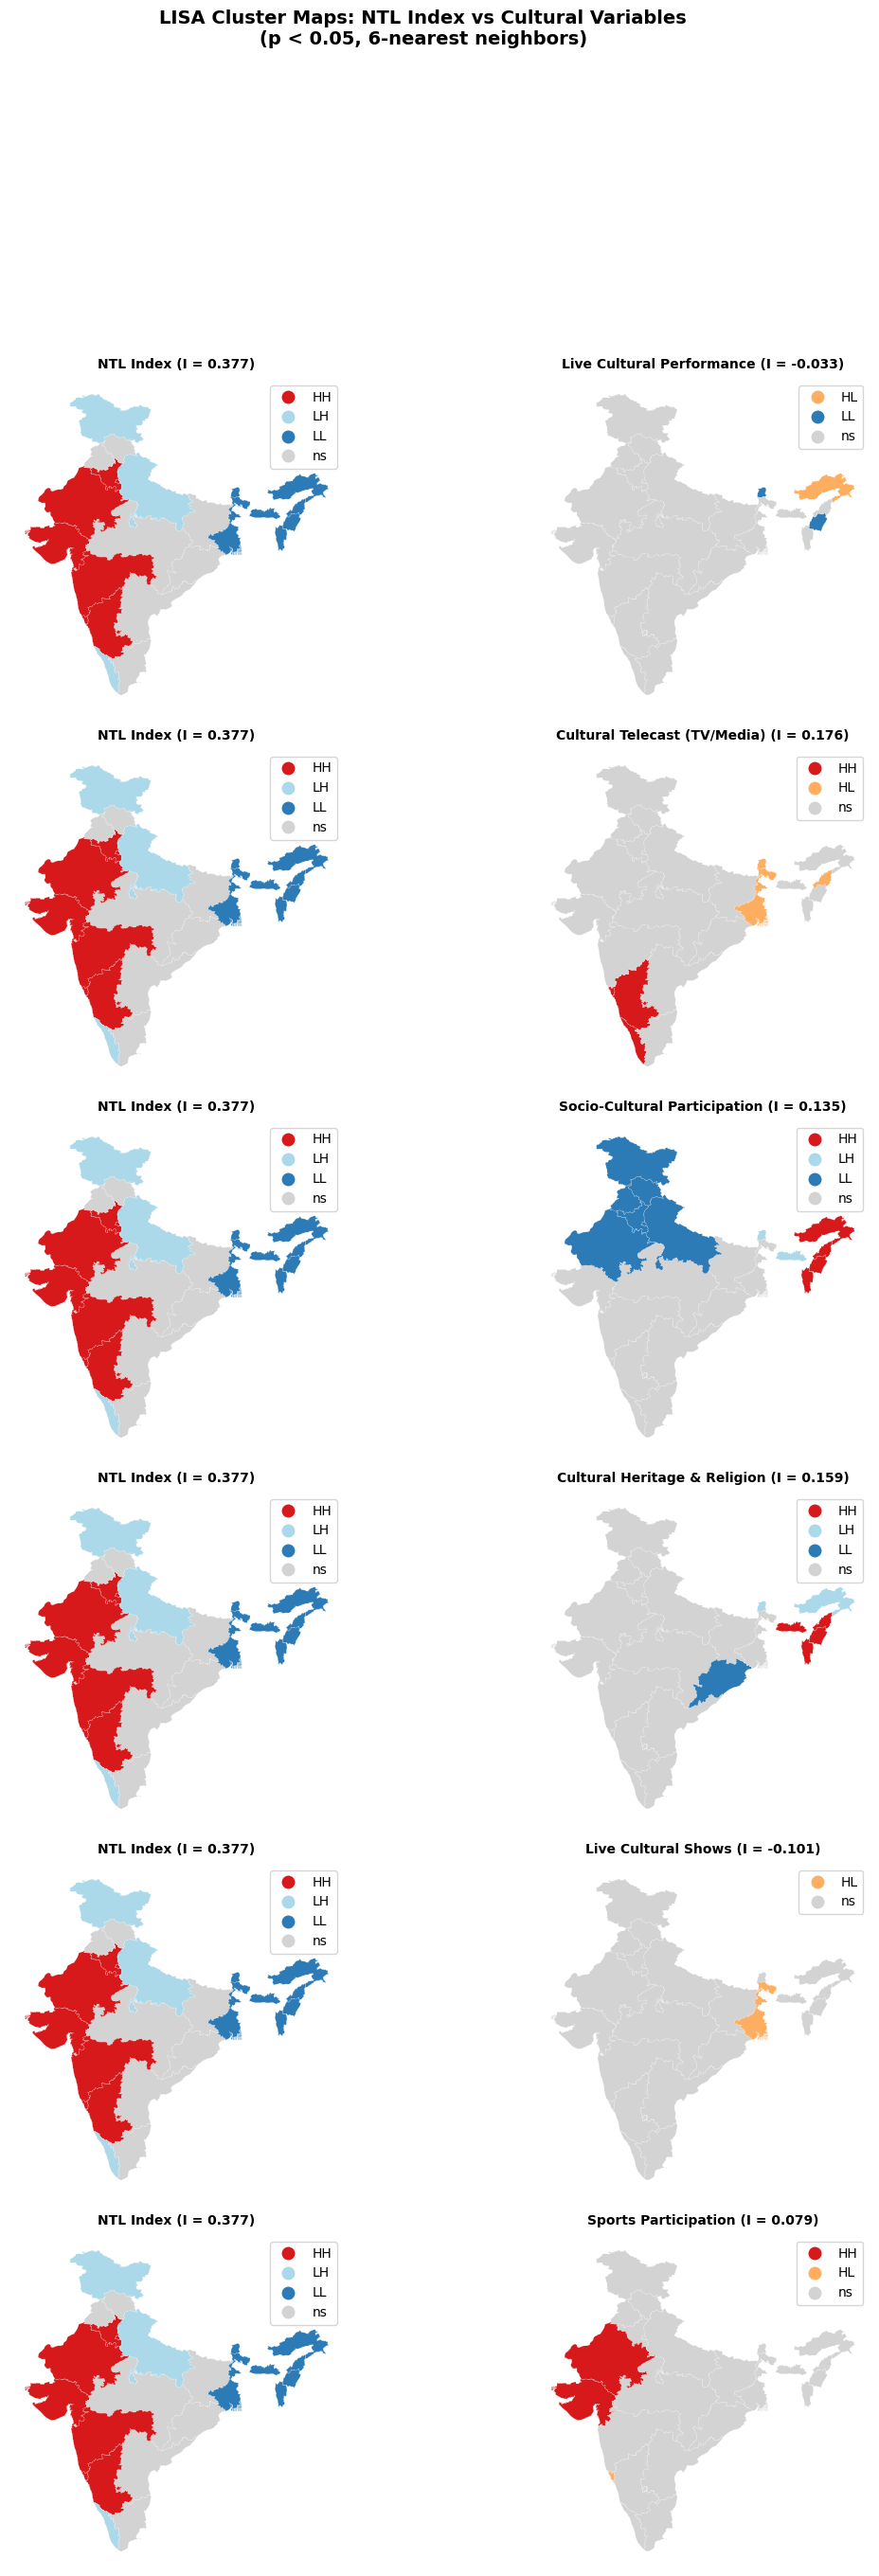

In [ ]:
# Compute LISA for NTL Index
lisa_ntl = Moran_Local(gdf_analysis["NTL_index"].values, W, permutations=999, seed=12345)

# Compute LISA for each cultural variable
lisa_cultural = {}
for var in variables:
    lisa_cultural[var] = Moran_Local(gdf_analysis[var].values, W, permutations=999, seed=12345)

# Compute Global Moran I values once
moran_ntl_global = Moran(gdf_analysis["NTL_index"].values, W, permutations=999)
moran_cultural_global = {}
for var in variables:
    moran_cultural_global[var] = Moran(gdf_analysis[var].values, W, permutations=999)

# Plot NTL LISA alongside each cultural variable LISA
fig, axes = plt.subplots(len(variables), 2, figsize=(14, 5 * len(variables)))

for i, var in enumerate(variables):
    # Left: NTL Index LISA cluster map
    lisa_cluster(lisa_ntl, gdf_analysis, p=0.05, ax=axes[i, 0])
    axes[i, 0].set_title(
        f"NTL Index (I = {moran_ntl_global.I:.3f})",
        fontsize=10, fontweight="bold", pad=8,
    )
    axes[i, 0].set_axis_off()

    # Right: Cultural variable LISA cluster map
    lisa_cluster(lisa_cultural[var], gdf_analysis, p=0.05, ax=axes[i, 1])
    axes[i, 1].set_title(
        f"{var_labels[var]} (I = {moran_cultural_global[var].I:.3f})",
        fontsize=10, fontweight="bold", pad=8,
    )
    axes[i, 1].set_axis_off()

fig.suptitle(
    "LISA Cluster Maps: NTL Index vs Cultural Variables\n(p < 0.05, 6-nearest neighbors)",
    fontsize=14, fontweight="bold", y=1.01,
)
fig.subplots_adjust(hspace=0.12, wspace=0.05)
plt.show()


### 10.2 Moran Scatterplots

Moran scatterplots show the relationship between each variable and its spatial lag (average of neighbors). The four quadrants correspond to the LISA cluster types: HH (upper-right), LL (lower-left), HL (lower-right), LH (upper-left).

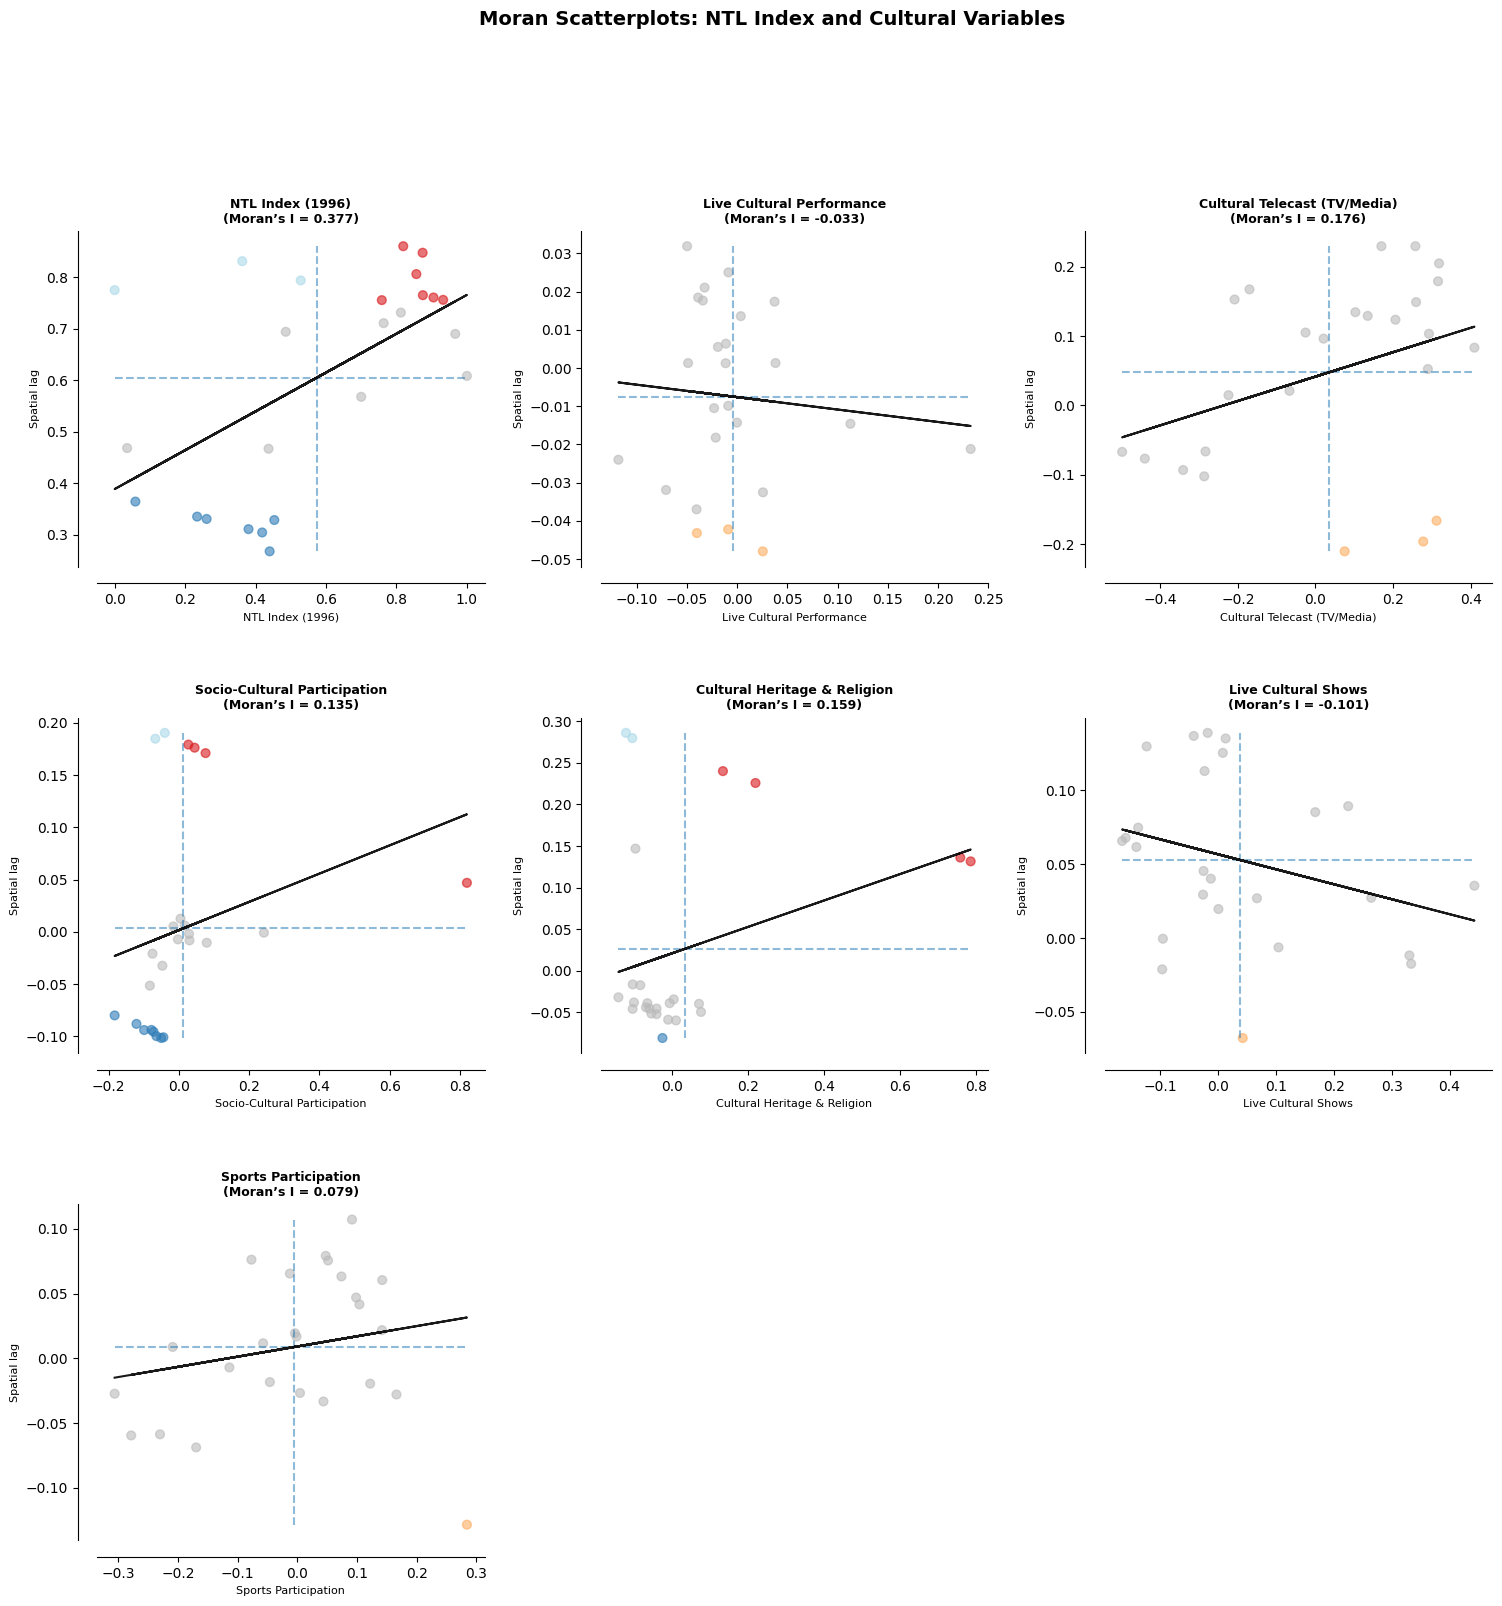

In [ ]:
# Moran scatterplots for NTL Index and all cultural variables
all_lisa = {"NTL_index": lisa_ntl}
all_lisa.update(lisa_cultural)

all_labels = {"NTL_index": "NTL Index (1996)"}
all_labels.update(var_labels)

fig, axes = plt.subplots(3, 3, figsize=(18, 17))
axes = axes.flatten()

plot_vars = ["NTL_index"] + variables
for i, var in enumerate(plot_vars):
    moran_scatterplot(all_lisa[var], p=0.05, zstandard=False, aspect_equal=False, ax=axes[i])
    moran_global = Moran(gdf_analysis[var].values, W, permutations=999)
    axes[i].set_title(
        f"{all_labels[var]}\n(Moran\u2019s I = {moran_global.I:.3f})",
        fontsize=9, fontweight="bold", pad=6,
    )
    axes[i].set_xlabel(all_labels[var], fontsize=8)
    axes[i].set_ylabel("Spatial lag", fontsize=8)

# Hide unused axes
for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Moran Scatterplots: NTL Index and Cultural Variables",
    fontsize=14, fontweight="bold", y=1.01,
)
fig.subplots_adjust(hspace=0.45, wspace=0.3)
plt.show()


## 11. High vs Low Development: Cultural Profiles

Comparing the average cultural participation of states above and below the median NTL per capita. This provides a direct answer to the question: do economically developed and underdeveloped regions differ in their cultural profile?

Median NTL Index: 0.528
High NTL group: 13 states
Low NTL group: 12 states

Mean Cultural Participation by Development Group
dev_group       High NTL  Low NTL
LC_Performance    0.0013  -0.0108
LC_Telecast       0.1751  -0.1150
SC               -0.0418   0.0722
CH_relig         -0.0357   0.1080
LC_shows          0.0836  -0.0126
Sports           -0.0122   0.0020


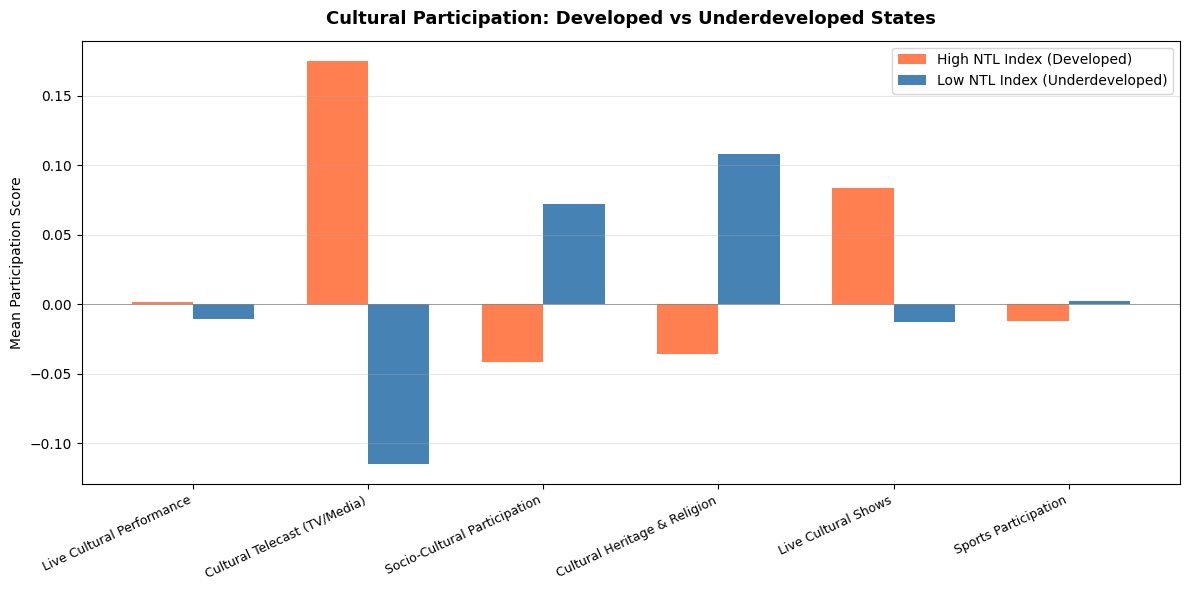


Mann-Whitney U Tests (High NTL vs Low NTL)
Live Cultural Performance           U =     74  p = 0.849   
Cultural Telecast (TV/Media)        U =    126  p = 0.010 *
Socio-Cultural Participation        U =     53  p = 0.183   
Cultural Heritage & Religion        U =     71  p = 0.724   
Live Cultural Shows                 U =    102  p = 0.201   
Sports Participation                U =     79  p = 0.978   


In [ ]:
# Split states into high/low development groups based on NTL Index
median_ntl = gdf_analysis["NTL_index"].median()
gdf_analysis["dev_group"] = np.where(
    gdf_analysis["NTL_index"] >= median_ntl, "High NTL", "Low NTL"
)

print(f"Median NTL Index: {median_ntl:.3f}")
print(f"High NTL group: {(gdf_analysis['dev_group'] == 'High NTL').sum()} states")
print(f"Low NTL group: {(gdf_analysis['dev_group'] == 'Low NTL').sum()} states")

# Group means
group_means = gdf_analysis.groupby("dev_group")[variables].mean()
print("\nMean Cultural Participation by Development Group")
print("=" * 70)
print(group_means.T.round(4).to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(variables))
width = 0.35

bars1 = ax.bar(x - width / 2, group_means.loc["High NTL"], width,
               label="High NTL Index (Developed)", color="coral")
bars2 = ax.bar(x + width / 2, group_means.loc["Low NTL"], width,
               label="Low NTL Index (Underdeveloped)", color="steelblue")

ax.set_ylabel("Mean Participation Score")
ax.set_title("Cultural Participation: Developed vs Underdeveloped States",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels([var_labels[v] for v in variables], rotation=25, ha="right", fontsize=9)
ax.legend(loc="upper right")
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Mann-Whitney U tests for group differences
print("\nMann-Whitney U Tests (High NTL vs Low NTL)")
print("=" * 60)
for var in variables:
    high = gdf_analysis[gdf_analysis["dev_group"] == "High NTL"][var]
    low = gdf_analysis[gdf_analysis["dev_group"] == "Low NTL"][var]
    u_stat, p_val = stats.mannwhitneyu(high, low, alternative="two-sided")
    sig = "*" if p_val < 0.05 else (" ." if p_val < 0.10 else "  ")
    print(f"{var_labels[var]:<35} U = {u_stat:>6.0f}  p = {p_val:.3f} {sig}")


## 12. Summary of Findings

**Economic development transforms the character of cultural participation.**

Using the Nighttime Lights Index (NTL, normalized 0-1) as a proxy for economic development:

1. **Cultural Telecast (TV/Media)** shows the strongest *positive* correlation with the NTL Index --- economically developed states have significantly higher media-based cultural consumption. This reflects TV/media infrastructure availability that comes with economic development.

2. **Socio-Cultural Participation** shows a significant *negative* correlation with the NTL Index --- community-based cultural engagement is more prevalent in less developed states, where commercial entertainment infrastructure is limited.

3. **Cultural Heritage & Religion** shows a negative association with the NTL Index --- poorer states (especially in the Northeast) have stronger religious and heritage-based cultural participation. Culture in these regions is embedded in community and religious life rather than consumed through media.

4. **Live Cultural Shows** are marginally higher in developed states with urban centers (Delhi, Chandigarh, Maharashtra, Goa), reflecting commercial entertainment markets.

5. **LISA cluster maps** reveal that the spatial clustering of cultural variables mirrors the economic geography: the western-southern prosperity belt overlaps with high telecast/shows clusters, while the eastern-northeastern poverty belt overlaps with high heritage/religion clusters.

6. **The core insight:** Economic development does not increase or decrease cultural participation overall --- it shifts its character. States with a high NTL Index *consume* culture through modern infrastructure (TV, commercial shows). States with a low NTL Index *produce* culture through community and religious life.

**Limitation:** This analysis covers 25 of 32 states due to missing NTL data for 7 states/territories (including Assam and Tripura), which may underrepresent the Northeastern cultural signal.
